## RGI Project Part I - 2025/2026

- Gustavo Brazil (ist1116490)
- João Pires (ist1116478)
- Miguel Soares (ist190494)

---

### 1.1 Preprocessing and Data Loading

Make sure the spaCy English model is installed.

**Text processing pipeline:** Sentence segmentation with pysbd → lemmatisation, stopword/punctuation removal, noun phrase extraction with spacy. Lemmatisation was chosen over stemming to preserve readability and semantic coherence in vector representations.

(changes added pysbd to the spacy pipeline because i didn't like how spacy was splitting the sentences)

In [ ]:
import os
import spacy
import joblib
from spacy.language import Language
from pysbd.utils import PySBDFactory

# ── Configuration ─────────────────────────────────────────────────────────────
BASE_PATH  = "BBC News Summary"
PROC_FILE  = "processed_data.joblib"

# Load once globally to avoid redundant model loads
nlp = spacy.load("en_core_web_sm")

try:
    @Language.factory("pysbd")
    def create_pysbd_component(nlp, name):
        return PySBDFactory(nlp)
except ValueError:
    pass

nlp.add_pipe("pysbd", first=True)

# ── Preprocessing ─────────────────────────────────────────────────────────────
def preprocess_text(text): #!!
    """Sentence segmentation, lemmatisation, stopword removal, noun-phrase extraction."""

    doc = nlp(text)
    sentences, processed_sentences = [], []

    for sent in doc.sents:
        strip_text = sent.text.strip()

        if not strip_text: continue

        tokens = [
            token.lemma_.lower()
            for token in sent
            if not token.is_stop and not token.is_punct and token.text.strip()
        ]
        noun_phrases = [chunk.text.lower() for chunk in sent.noun_chunks]

        if not tokens + noun_phrases: continue

        sentences.append(strip_text)
        processed_sentences.append(tokens + noun_phrases)

    return sentences, processed_sentences

# ── Dataset loader ─────────────────────────────────────────────────────────────
def load_bbc_dataset(base_path): #!!
    """Reads the BBC News folder structure and returns a list of document dicts."""
    categories  = ["business", "entertainment", "politics", "sport", "tech"]
    articles_dir = os.path.join(base_path, "News Articles")
    summaries_dir = os.path.join(base_path, "Summaries")
    data = []

    for cat in categories:
        cat_path = os.path.join(articles_dir, cat)
        if not os.path.exists(cat_path):
            continue
        for filename in sorted(f for f in os.listdir(cat_path) if f.endswith(".txt")):
            art_path = os.path.join(cat_path, filename)
            sum_path = os.path.join(summaries_dir, cat, filename)
            with open(art_path, "r", encoding="latin1") as fa, open(sum_path,  "r", encoding="latin1") as fs:
                content     = fa.read()
                ref_summary = fs.read()

            sents, proc_sents = preprocess_text(content)
            data.append({
                "doc_id":              f"{cat}_{filename.split('.')[0]}",
                "category":            cat,
                "original_text":       content,
                "sentences":           sents,
                "processed_sentences": proc_sents,
                "reference_summary":   ref_summary,
            })
    return data

# ── Main ───────────────────────────────────────────────────────────────────────
if os.path.exists(PROC_FILE):
    print(f"Loading pre-processed data from {PROC_FILE}...")
    D = joblib.load(PROC_FILE)
else:
    print("Starting dataset loading and NLP preprocessing...")
    D = load_bbc_dataset(BASE_PATH)
    joblib.dump(D, PROC_FILE)
    print("Processing complete.")

print(f"Successfully loaded {len(D)} documents.")

Starting dataset loading and NLP preprocessing...
Processing complete.
Successfully loaded 2225 documents.


### 1.2 Indexing Function

The hybrid index contains:
- **Inverted index** (lexical / sparse) — stores per-document term frequencies  
- **Embeddings** (dense / semantic) — one vector per sentence, built with **two** encoder LLMs with distinct profiles:
  - `all-MiniLM-L6-v2` — general-purpose bi-encoder, trained with contrastive learning on diverse corpora  
  - `multi-qa-MiniLM-L6-cos-v1` — fine-tuned specifically for semantic similarity and question-answering tasks

Using two encoders lets us compare sparse vs. dense representations and assess whether domain-specific fine-tuning affects summarisation quality.

* doc_lengths is useless
* change the way the text embeddings are made
* changed the way the dictionary is created so we dont use the defaultdic

In [2]:
import time, sys, math, os, joblib
import numpy as np
from collections import Counter, defaultdict
from sentence_transformers import SentenceTransformer
from huggingface_hub import login
from transformers import logging as transformers_logging
from tqdm import tqdm

transformers_logging.set_verbosity_error()

# ── Load HuggingFace token from environment (never hardcode credentials) ───────
HF_TOKEN = os.environ.get("HF_TOKEN", "")
if HF_TOKEN:
    login(HF_TOKEN)
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# ── Two encoder LLMs with distinct profiles ───────────────────────────────────
ENCODER_MODELS = {
    "minilm_general": "all-MiniLM-L6-v2",          # general-purpose contrastive encoder
    "minilm_qa":      "multi-qa-MiniLM-L6-cos-v1", # QA/similarity fine-tuned encoder
}

def indexing(D, args=None, filename="hybrid_index.joblib"):
    """
    Build a hybrid index (inverted + embeddings for 2 encoders).

    Returns
    -------
    I            : dict  — the index
    indexing_time: float — wall-clock seconds (0 if loaded from cache)
    size_bytes   : int   — sys.getsizeof(I)
    """
    if os.path.exists(filename):
        print(f"Loading existing index from {filename}...")
        I = joblib.load(filename)
        return I, 0.0, sys.getsizeof(I)

    print("Index not found. Building index...")
    start = time.time()

    # ── Lexical (inverted) index ───────────────────────────────────────────────
    inverted_index = dict()

    categories  = ["business", "entertainment", "politics", "sport", "tech"]
    cat_len_counter = dict()

    # Pre-load both encoders once
    encoders = {key: SentenceTransformer(name) for key, name in ENCODER_MODELS.items()}
    doc_embeddings = {key: {} for key in ENCODER_MODELS}
    doc_sent_embeddings = {key: {} for key in ENCODER_MODELS}

    for doc in D:
        #Extracting information
        doc_id = doc["doc_id"]

        #Creates a dictionary where key "tech" stores the word count and "tech_counter" stores the number of tech docs
        cat_len_counter[doc["category"]] = cat_len_counter.get(doc["category"],0) + np.average([len(x) for x in doc["processed_sentences"]])
        cat_len_counter[doc["category"]+"_counter"] = cat_len_counter.get(doc["category"]+"_counter",0)+1

        # Sparse: populate inverted index
        for sent_terms in doc["processed_sentences"]:
            for term in sent_terms:

                inverted_index[term] = inverted_index.get(term,dict())
                inverted_index[term][doc_id] = inverted_index[term].get(doc_id,0) + 1

        # Embeddings
        for enc_key, model in encoders.items():

            doc_embeddings[enc_key][doc_id] = model.encode(doc["original_text"])   #changed to use the original text
            doc_sent_embeddings[enc_key][doc_id] = model.encode(doc["sentences"])   #added the direct processing of sentences

    indexing_time = time.time() - start

    I = {
        "inverted_index":    inverted_index,
        "embeddings":        doc_embeddings,   # {"minilm_general": {doc_id: array}, ...}
        "sent_embeddings":   doc_sent_embeddings,
        "total_docs":        len(D),
        "encoder_models":    ENCODER_MODELS,
        # Collection-level avg sentence length (needed for BM25)
        "avg_sent_len":      {cat:cat_len_counter[cat]/cat_len_counter[cat+"_counter"] for cat in categories}
         #CONSIDER SAVING AVG SENT LEN OF CATEGORIES TO USE IN BM25
    }

    joblib.dump(I, filename)
    print(f"Index built in {indexing_time:.1f}s and saved to {filename}.")
    return I, indexing_time, sys.getsizeof(I)

I, indexing_time, isize = indexing(D)
print(f"Indexing time: {indexing_time:.1f}s | In-memory size: {isize/1e6:.1f} MB")

d:\Learning\MECD\2sem\IPR\Project\1\.env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Index not found. Building index...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3548.13it/s]


Index built in 715.5s and saved to hybrid_index.joblib.
Indexing time: 715.5s | In-memory size: 0.0 MB


---

### 2.1 Keyword Extraction Function 

Extracts the top-`p` informative keywords using **TF-IDF** scoring. A semantic redundancy filter (cosine similarity) removes near-duplicate terms. The output preserves the original TF-IDF ranking order as required by the spec (`ordered set of p keywords`).

changes:
* removed Counter function and added dictionary comprehension
* fetch_TF function so it is based on the Index created
* log10 base instead of log

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import torch
import re
from transformers import pipeline

def fetch_TF(doc,I):
    TF_dict = dict()
    for term in I["inverted_index"]:
        if doc["doc_id"] in I["inverted_index"][term]:
            TF_dict[term]=I["inverted_index"][term][doc["doc_id"]]
    return TF_dict

def output_cleaner(output, model, p): #!!
    BLACKLIST = {
        "no json", "no markdown", "no explanations", "output",
        "keywords", "text", "rules", "comma", "list"
    }
    try:
        if model == DECODER_MODELS["a"]:
            # Modelo A — formato comma-separated
            cleaned  = output.split("assistant\n")[-1].strip()
            keywords = [word.strip() for word in cleaned.split(',')]

        else:
            # Modelo B — formato JSON array
            cleaned  = output.split("Output: [")[-1].split("]")[0]
            keywords = [
                word.strip().strip('"').strip("'")
                for word in cleaned.split(',')
            ]

        # Filtros comuns a ambos os modelos
        keywords = [
            k for k in keywords
            if k
            and len(k) < 50
            and k.lower() not in BLACKLIST
            and "\n" not in k
        ]

        # Remove duplicados preservando ordem
        keywords = list(dict.fromkeys(keywords))

        return keywords[:p]

    except:
        return []

DECODER_MODELS = {
    "a": "Qwen/Qwen2.5-1.5B-Instruct",  #multi-purpose (tuned for instructions)
    "b": "Qwen/Qwen3-Reranker-0.6B"     #embeddings and ranking tasks
}

def keyword_extraction(doc, p, I, method="tfidf", model=DECODER_MODELS["a"], zeroshot=True): #!!

    N = I["total_docs"]

    if method == "tfidf":
        TF_dict = fetch_TF(doc, I)
        doc_norm = np.sqrt(np.sum(np.array([x for x in TF_dict.values()])**2))
        scores = {}
        for term, tf in TF_dict.items():
            df = len(I["inverted_index"].get(term, {}))
            if df == 0:
                continue
            tf_doc = 1 + np.log10(tf)
            tf_q   = 1 + np.log10(1)
            idf    = np.log10(N / df)
            scores[term] = tf_doc / doc_norm * tf_q * idf
            candidates = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:p]
        return [x for x, y in candidates]

    elif method == "prompting":

        # ── Prompts para o Modelo A (Qwen2.5-1.5B-Instruct) ──────────────────
        if model == DECODER_MODELS["a"]:
            prompt_zeroshot = f"""<|im_start|>system
You are a keyword extraction algorithm. Extract the {p} most important keywords from the text. Return ONLY a comma-separated list. No explanations, no JSON, no markdown.
<|im_end|>
<|im_start|>user
Text: "{doc["original_text"][:600]}"
Output:<|im_end|>
<|im_start|>assistant
"""
            prompt_fewshot = f"""<|im_start|>system
You are a keyword extraction algorithm.
Your task: read the text and return the {p} most specific and relevant keywords.
Rules:
- Return ONLY a comma-separated list
- No explanations
- No JSON
- No markdown
- Keywords must come FROM the text
<|im_end|>
<|im_start|>user
Text: "{doc["original_text"][:600]}"
Output:<|im_end|>
<|im_start|>assistant
"""

        # ── Prompts para o Modelo B (Qwen3-Reranker-0.6B) ────────────────────
        else:
            prompt_zeroshot = f"""
System/Instruction: You are an expert keyword extraction algorithm.
Analyze the text and extract the {p} most important keywords.
Output ONLY a valid JSON array of strings. Do not include markdown blocks, explanations, or any other text.

Now, process the following text.
Text: {doc["original_text"][:600]}

Output: ["""

            prompt_fewshot = f"""
System/Instruction: You are an expert keyword extraction algorithm.
You MUST extract EXACTLY {p} keywords. Not less, not more.
Output ONLY a valid JSON array of exactly {p} strings.

Now, process the following text.
Text: {doc["original_text"][:600]}

Output: ["""

        prompt_chosen = prompt_zeroshot if zeroshot else prompt_fewshot

        pipe = pipeline("text-generation", model=model, torch_dtype=torch.float16, device_map="auto")
        output = pipe(prompt_chosen, max_new_tokens=50, temperature=0.1)[0]['generated_text']
        word_list = output_cleaner(output, model, p)
        return word_list

    return []

TF-IDF keyword extraction seems to give significantly more importance to the noun phrases extracted, probably on account of their DF being statitically lower

### 2.2 Decoder LLMs for Keyword Extraction (Generative approach)

We use **two** lightweight autoregressive decoder LLMs with distinct profiles:

| Model |  Pretraining focus |
|---|---|
| `Qwen/Qwen2.5-1.5B-Instruct` |  Multi-Purpose |
| `Qwen/Qwen3-Reranker-0.6B` |  Embeddings and Ranking tasks |


In [ ]:
import joblib, os
from tqdm import tqdm

LLM_KEYWORDS_FILE = "llm_keywords_results.joblib"

# Carrega progresso anterior se existir
if os.path.exists(LLM_KEYWORDS_FILE):
    all_llm_keywords = joblib.load(LLM_KEYWORDS_FILE)
    print(f"Retomando de {len(all_llm_keywords)} documentos processados.")
else:
    all_llm_keywords = {}

# 4 documentos por categoria que ainda não foram processados
categories = ["business", "entertainment", "politics", "sport", "tech"]
docs_to_process = []
for cat in categories:
    cat_docs = [d for d in D if d["category"] == cat and d["doc_id"] not in all_llm_keywords]
    docs_to_process.extend(cat_docs[:4])

print(f"Documentos a processar: {len(docs_to_process)} ({len(categories)} categorias × 4)")

if docs_to_process:
    try:
        for doc in tqdm(docs_to_process, desc="Extracting keywords"):
            doc_id = doc["doc_id"]
            all_llm_keywords[doc_id] = {
                "model_a_zeroshot": keyword_extraction(
                    doc, 5, I, method="prompting",
                    model=DECODER_MODELS["a"], zeroshot=True
                ),
                "model_a_fewshot": keyword_extraction(
                    doc, 5, I, method="prompting",
                    model=DECODER_MODELS["a"], zeroshot=False
                ),
                "model_b_zeroshot": keyword_extraction(
                    doc, 5, I, method="prompting",
                    model=DECODER_MODELS["b"], zeroshot=True
                ),
                "model_b_fewshot": keyword_extraction(
                    doc, 5, I, method="prompting",
                    model=DECODER_MODELS["b"], zeroshot=False
                ),
                "tfidf": keyword_extraction(
                    doc, 5, I, method="tfidf"
                ),
            }

            # Checkpoint a cada documento
            joblib.dump(all_llm_keywords, LLM_KEYWORDS_FILE)

        print("Concluído!")

    except KeyboardInterrupt:
        joblib.dump(all_llm_keywords, LLM_KEYWORDS_FILE)
        print("Interrompido. Progresso guardado.")
else:
    print("Todos os documentos já processados.")

Documentos a processar: 20 (5 categorias × 4)


Extracting keywords: 100%|██████████| 20/20 [26:55<00:00, 80.77s/it]

Concluído!


In [6]:
import pandas as pd
import joblib

# Carrega o ficheiro
all_llm_keywords = joblib.load("llm_keywords_results.joblib")

# Converte para DataFrame
rows = []
for doc_id, kw_dict in all_llm_keywords.items():
    rows.append({
        "doc_id":           doc_id,
        "category":         doc_id.split("_")[0],
        "model_a_zeroshot": ", ".join(kw_dict.get("model_a_zeroshot", [])),
        "model_a_fewshot":  ", ".join(kw_dict.get("model_a_fewshot",  [])),
        "model_b_zeroshot": ", ".join(kw_dict.get("model_b_zeroshot", [])),
        "model_b_fewshot":  ", ".join(kw_dict.get("model_b_fewshot",  [])),
        "tfidf":            ", ".join(kw_dict.get("tfidf",            [])),
    })

df = pd.DataFrame(rows)

# Guarda em CSV para abrir no Excel
df.to_csv("keywords_comparison.csv", index=False)
print("Guardado em keywords_comparison.csv")

# Mostra no notebook
df

Guardado em keywords_comparison.csv


,doc_id,category,model_a_zeroshot,model_a_fewshot,model_b_zeroshot,model_b_fewshot,tfidf
0,business_001,business,"ad_sales, quarterly_profit, profit_boost, time...","advertising, sales, profit, Time Warner, internet","sales, profit, Time Warner, Q4, Internet","web, page","timewarner, catwoman, aol europe, aol, warner"
1,business_002,business,"dollar, euro, Greenspan, trade deficit, savings","dollar, euro, greenspan, speech, trade deficit","dollar, euro, federal reserve, us, trade deficit","dollar, euro, federal, reserve","greenspan, the current account deficit, dollar..."
2,business_003,business,"Yukos, Rosneft, loan, Yugansk, asset","Rosneft, Yukos, Yugansk, loan, repayment","Yukos, loan, buy, tax, repayment","Yukos, loan, 900m, 9.3bn, repayment","yugansk, rosneft, menatep, yukos, seizure"
3,business_004,business,"BA, fuel, profits, pricing, revenue","fuel, profits, BA, fuel prices, fuel surcharge","high fuel prices, BA, profit, 40% drop","fuel price, profit, 40%, 47.3%, BA","ba, surcharge, ba's profits, eddington, cargo"
4,entertainment_001,entertainment,"Christmas, message, tree, sculpture","Christmas tree, text message, Bluetooth, sculp...","unveils, tree, Tate Britain, interactive, Chri...","unwrapped, tree, messages, tate, gallery","wentworth, sculptor, gallery, spruce, tree"
5,entertainment_002,entertainment,"Andersen, Denmark, Hans Christian, Jarre, Jean...","Jean-Michel Jarre, Copenhagen, Hans Christian ...","Jarre, French, concert, Copenhagen, Hans Chris...","Jarre, concert, Copenhagen, fairy-tale, birth","jarre, andersen, bloom, frederik, odense"
6,entertainment_003,entertainment,"Capra, Jerry Springer, musical, It's A Wonderf...","musical, Capra, film, producer, Jerry Springer...","musical, Capra, JERRY, SPEND, THODAY","musical, Capra, James Stewart, Thoday, Spend S...","thoday, a wonderful life, mr thoday, doren, capra"
7,entertainment_004,entertainment,"books, Richard, Judy, winners, sales","Richard and Judy, book award, sales boost, TV ...","The American Boy, Feel, The Lovely Bones, Alic...","The American Boy, Feel, The Lovely Bones, Alic...","madeley, judy, this year's winner, top books, ..."
8,politics_001,politics,"maternity, pay, rise, mother, leave",maternity_pay_rise,"Labour, maternity pay, increase, 1400, 9 months","Labour, maternity, pay, rise, UK","â£1,400, maternity, maternity pay, new mothers..."
9,politics_002,politics,"Cabinet Office, deletion, e-mails, Freedom of ...","e-mails, Cabinet Office, freedom of informatio...","deletion, e-mails, freedom of information, cab...","deletion, e-mails, freedom, information, laws","deletion, mr thomas, mr beith, the information..."


In [7]:
# ── Inspect LLM keyword outputs ───────────────────────────────────────────────
for i, (doc_id, kw_dict) in enumerate(all_llm_keywords.items()):
    print(f"Document: {doc_id}")
    for model_key, kws in kw_dict.items():
        print(f"  [{model_key}] {kws}")
    print("-" * 50)
    if i >= 20:
        break

Document: business_001
  [model_a_zeroshot] ['ad_sales', 'quarterly_profit', 'profit_boost', 'time_warner', 'google']
  [model_a_fewshot] ['advertising', 'sales', 'profit', 'Time Warner', 'internet']
  [model_b_zeroshot] ['sales', 'profit', 'Time Warner', 'Q4', 'Internet']
  [model_b_fewshot] ['web', 'page']
  [tfidf] ['timewarner', 'catwoman', 'aol europe', 'aol', 'warner']
--------------------------------------------------
Document: business_002
  [model_a_zeroshot] ['dollar', 'euro', 'Greenspan', 'trade deficit', 'savings']
  [model_a_fewshot] ['dollar', 'euro', 'greenspan', 'speech', 'trade deficit']
  [model_b_zeroshot] ['dollar', 'euro', 'federal reserve', 'us', 'trade deficit']
  [model_b_fewshot] ['dollar', 'euro', 'federal', 'reserve']
  [tfidf] ['greenspan', 'the current account deficit', 'dollar gains', 'greenspan speech', 'the federal reserve head']
--------------------------------------------------
Document: business_003
  [model_a_zeroshot] ['Yukos', 'Rosneft', 'loan', 'Y

### 2.3 Summarization Function

Supports four extraction modes (`tfidf`, `bm25`, `embeddings`, `rrf`) plus `prompting`.

**MMR correction:** the formula from the paper is  
$MMR(s) = (1-\lambda)\cdot sim(s,d) - \lambda \sum_{v\in S} sim(s,v)$ 
where **higher λ → more diversity** (λ=1 = maximum anti-redundancy). This is now implemented correctly.

**RRF correction:** the spec fixes `µ = 5` (previously `k=60`).

In [ ]:
import math
import numpy as np
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity
import re
from transformers import T5ForConditionalGeneration, T5Tokenizer, BartForConditionalGeneration, BartTokenizer

# ── Sentence scoring ──────────────────────────────────────────────────────────
def get_sentence_scores(d, D_collection, I, method="bm25", k1=1.2, b=0.75, enc_key="minilm_general"):  #!!
    """
    Score every sentence in document d.

    Parameters
    ----------
    D_collection : list — full corpus (needed for BM25 avg sentence length)
    enc_key      : str  — which encoder embedding to use ('minilm_general' or 'minilm_qa')
    """
    doc_id         = d["doc_id"]
    sentences_terms = d["processed_sentences"]
    N              = I["total_docs"]
    scores         = []

    n_sentences = len(sentences_terms)
    scores_index = [str(x) for x in range(n_sentences)]

    if method in ("tfidf", "bm25"):
        # Use pre-computed avg sentence length stored in the index
        avgsl = I["avg_sent_len"][d["category"]]

        TF_dict = fetch_TF(d,I)
        doc_norm = np.sqrt(np.sum(np.array([x for x in TF_dict.values()])**2))

        for sent_terms in sentences_terms:
            sent_len = len(sent_terms) #how many words does each sentence have
            if sent_len == 0:
                scores.append(0.0)
                continue

            s_score = 0.0
            counts  = Counter(sent_terms) #get term frequency of the sentence, can't use I because that is storing doc

            for term, tf_term_q in counts.items():
                df = len(I["inverted_index"].get(term, {}))
                if df == 0:
                    continue
                
                tf_term_doc = 1 + np.log10(TF_dict.get(term,0))

                idf = math.log10(N/df)

                if method == "tfidf":
                    #using Lnc.Ltn
                    s_score += tf_term_doc/doc_norm*tf_term_q*idf

                else:  # BM25
                    num      = tf_term_q * (k1 + 1)
                    den      = tf_term_q + k1 * (1 - b + b * (sent_len / avgsl))
                    s_score += idf * (num / den)

            scores.append(s_score)  #list scores in order of sentence

    elif method == "embeddings":
        
        sent_embs = I["sent_embeddings"][enc_key][doc_id]
        doc_embs    = I["embeddings"][enc_key][doc_id].reshape(1, -1)

        scores  = cosine_similarity(sent_embs, doc_embs).flatten().tolist()

    return np.array(scores)

# ── RRF fusion (µ=5 as per spec) ─────────────────────────────────────────────
def rrf_fusion(rankings, mu=5): #!!
    """Combine multiple sentence score arrays via Reciprocal Rank Fusion."""
    n              = len(rankings[0])
    rrf_scores     = np.zeros(n)
    for r_scores in rankings:
        # rank 0 = best
        ranks = n - 1 - np.argsort(np.argsort(r_scores))
        for i, rank in enumerate(ranks):
            rrf_scores[i] += 1.0 / (mu + rank)
    return rrf_scores

# ── MMR selection (formula matches spec: (1−λ)·sim(s,d) − λ·Σsim(s,v)) ───────
def mmr_selection(doc_id, sentence_scores, I, p, lambd=0.5, enc_key="minilm_general"): #!!
    """
    Select p sentences via Maximal Marginal Relevance.

    λ=0 → purely relevance-driven (no diversity)
    λ=1 → maximum diversity (minimum redundancy)
    """
    doc_emb          = I["embeddings"][enc_key][doc_id]
    embs             = I["sent_embeddings"][enc_key][doc_id]
    selected_indices = []
    remaining        = list(range(len(sentence_scores)))

    for _ in range(min(p, len(sentence_scores))):
        mmr_scores = []
        for idx in remaining:

            relevance  = cosine_similarity(
                embs[idx].reshape(1, -1), doc_emb.reshape(1, -1)
            )[0][0]
            #relevance  = norm_scores[idx]

            if not selected_indices:
                redundancy = 0.0
            else:
                sims       = cosine_similarity(
                    embs[idx].reshape(1, -1), embs[selected_indices]
                )
                redundancy = float(np.sum(sims))   # sum, not max, as per formula

            # Correct formula: (1−λ)·relevance − λ·redundancy
            mmr_scores.append((1 - lambd) * relevance - lambd * redundancy)

        best_in_remaining = int(np.argmax(mmr_scores))
        best_global       = remaining.pop(best_in_remaining)
        selected_indices.append(best_global)

    return selected_indices

# -- Generative output cleaner -------
def gen_cleaner(text, p, l=None):

    text = re.sub(r'[^.!?]*\w[^.!?]*$', '', text).strip()
    sentences = re.findall(r'[^.!?]+[.!?]+', text)
    sentences = [s.strip() for s in sentences]

    if l:
        result = ""
        for s in sentences:
            # Check if adding the next sentence exceeds the limit
            if len(result) + len(s) + (1 if result else 0) > l:
                break
            result += (" " + s if result else s)
        return result.strip()
    else:
        return " ".join(sentences[:p]).strip()

# ── Main summarization orchestrator ──────────────────────────────────────────
def summarization(d, p, I, D_collection, args=None, l=None): #!!
    """
    Summarise document d.

    Parameters
    ----------
    p            : int  — max number of sentences (extractive) or tokens (generative)
    l            : int  — max characters (optional, applied post-selection)
    D_collection : list — full corpus (passed through to BM25)
    args         : dict — method, lambda, enc_key, llm_pipeline, …

    Returns
    -------
    Extractive : list of (sentence_position, score) tuples ordered by position
    Generative : list with a single summary string
    """
    args   = args or {}
    method = args.get("method", "rrf")
    lambd  = args.get("lambda", 0.5)
    enc_key = args.get("enc_key", "minilm_general")

    # ── Extractive ────────────────────────────────────────────────────────────
    if method in ("tfidf", "bm25", "embeddings", "rrf"):
        if method == "rrf":
            s_bm25   = get_sentence_scores(d, D_collection, I, method="bm25",       enc_key=enc_key)
            s_emb    = get_sentence_scores(d, D_collection, I, method="embeddings",  enc_key=enc_key)
            scores   = rrf_fusion([s_bm25, s_emb])
        else:
            scores   = get_sentence_scores(d, D_collection, I, method=method, enc_key=enc_key)

        indices  = mmr_selection(d["doc_id"], scores, I, p, lambd=lambd, enc_key=enc_key)
        indices_sorted = sorted(indices)   # chronological order

        # Build output: ordered list of (position, score) pairs
        result = [(i, float(scores[i])) for i in indices_sorted]

        # Apply character limit if requested
        if l is not None:
            filtered, total = [], 0
            for pos, score in result:
                sent = d["sentences"][pos]
                if total + len(sent) <= l:
                    filtered.append((pos, score))
                    total += len(sent)
            result = filtered

        return result   # list of (position, score)

    # ── Generative ────────────────────────────────────────────────────────────
    elif method == "prompting":
        prompt = args.get("prompt","a")
        model_name = args.get("model", "google/flan-t5-base")

        MODEL_PARAMS = dict(
            max_new_tokens=l*2 if l else 200,
            min_new_tokens=50,
            do_sample=False,          # greedy for seq2seq — more faithful
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3,
        )

        if not model_name:
            return [("Error: no Model provided", 0.0)]

        if prompt=="a": #mais estrutorado, markdown format
            prompt_chosen = f"""
### Document:
{d["original_text"]}

### Task:
Write a concise summary. Rules:
1. Use 3 to 5 sentences only.
2. State the main idea first.
3. Do NOT copy sentences verbatim.
4. Use a neutral, objective tone.

### Summary:"""
        else: #main a base de LN
            prompt_chosen = f""""
Summarize the following document in 3-4 sentences.
Focus on the main claim and key evidence only.
Do not include background context or minor details.

Document: {d["original_text"]}

Summary:"""

        if model_name == "google/flan-t5-base":
            tokenizer = T5Tokenizer.from_pretrained(model_name)
            model = T5ForConditionalGeneration.from_pretrained(model_name, torch_dtype=torch.float32)

            inputs = tokenizer(
                prompt_chosen,
                return_tensors="pt",
                max_length=1024,
                truncation=True,
            )
            with torch.no_grad():
                summary_ids = model.generate(
                    inputs["input_ids"],
                    attention_mask=inputs["attention_mask"],
                    **MODEL_PARAMS,
                )
            raw_out = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

            return gen_cleaner(raw_out,p,l if l else None)

        elif model_name == "facebook/bart-large-cnn":
            model = BartForConditionalGeneration.from_pretrained(model_name, torch_dtype=torch.float32)
            tokenizer = BartTokenizer.from_pretrained(model_name)

            inputs = tokenizer(
                prompt_chosen,
                return_tensors="pt",
                max_length=1024,
                truncation=True,
            )
            with torch.no_grad():
                summary_ids = model.generate(
                    inputs["input_ids"],
                    attention_mask=inputs["attention_mask"],
                    **MODEL_PARAMS,
                )
            raw_out = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

            return gen_cleaner(raw_out,p,l if l else None)
        
        else: return [("Error: Model provided not in list", 0.0)]
        return None  # single string in a list

### 2.4 Generate All Summaries

In [9]:
import os, joblib
from tqdm import tqdm

SUMMARIES_FILE = "summaries_results.joblib"
summary_args   = {"method": "rrf", "lambda": 0.5, "enc_key": "minilm_general"}
P              = 3   # sentences per summary

if os.path.exists(SUMMARIES_FILE):
    print(f"Loading summaries from {SUMMARIES_FILE}...")
    all_summaries = joblib.load(SUMMARIES_FILE)
else:
    print("Generating extractive summaries (RRF + MMR)...")
    all_summaries = {}
    try:
        for doc in tqdm(D, desc="Summarising"):
            all_summaries[doc["doc_id"]] = summarization(doc, P, I, D, summary_args)
        joblib.dump(all_summaries, SUMMARIES_FILE)
        print("Done.")
    except KeyboardInterrupt:
        joblib.dump(all_summaries, SUMMARIES_FILE)
        print("Interrupted. Progress saved.")

# Quick sanity check
doc0 = D[521]
sample = all_summaries[doc0["doc_id"]]
print("\nSample extractive summary (position, score):")
for pos, score in sample:
    print(f"  [{pos}] (score={score:.4f}) {doc0['sentences'][pos]}")

Generating extractive summaries (RRF + MMR)...


Summarising: 100%|██████████| 2225/2225 [02:16<00:00, 16.26it/s]

Done.

Sample extractive summary (position, score):
  [0] (score=0.2167) Neeson in bid to revive theatre
  [5] (score=0.4000) The Oscar-nominated actor, whose films include Schindler's List, Michael Collins and Star Wars: The Phantom Menace, said: "The Lyric is too important to the cultural and social life of Northern Ireland for this building to crumble and fall apart. "It gave me a start professionally.
  [7] (score=0.1325) "In those days, in the mid-70s, when I was there, we were doing a play every four weeks. "Belfast was not a pretty town to be living in.


### 3. Generative Summarisation

We run both decoder LLMs on the first 10 documents as a demonstration. Replace `[:10]` with `D` to run on the full collection.

In [10]:
GEN_SUMMARIES_FILE = "summaries_generative_results.joblib"

if os.path.exists(GEN_SUMMARIES_FILE):
    all_gen_summaries = joblib.load(GEN_SUMMARIES_FILE)
    print(f"Loaded {len(all_gen_summaries)} generative summaries.")
else:
    all_gen_summaries = {}

In [ ]:
categories  = ["business", "entertainment", "politics", "sport", "tech"]
docs_to_gen = [doc for doc in D for cat in categories for i in range(1,5) if doc["doc_id"]==f"{cat}_00{i}"]

#docs_to_gen = [d for d in D if d["doc_id"] not in all_gen_summaries][:10]

model_list = ["google/flan-t5-base","facebook/bart-large-cnn"]
prompt_list = ["a", "b"]


if docs_to_gen:
    for model in model_list:
        for prompt in prompt_list:

            gen_args = {"method": "prompting", "prompt": prompt, "model": model}

            for doc in tqdm(docs_to_gen, desc=f"Generative Summary — {model}|{prompt}"):
                doc_id = doc["doc_id"]

                if doc_id not in all_gen_summaries:
                    all_gen_summaries[doc_id] = {}
                if model not in all_gen_summaries[doc_id]:
                    all_gen_summaries[doc_id][model] = {}

                all_gen_summaries[doc_id][model][prompt] = summarization(doc, P, I, D, gen_args)
                
    joblib.dump(all_gen_summaries, GEN_SUMMARIES_FILE)
    print("Done.")
else:
    print("Nothing to process.")

Loading weights: 100%|██████████| 282/282 [00:00<00:00, 5902.81it/s]03:02<00:10, 10.19s/it]
Generative Summary — google/flan-t5-base|a: 100%|██████████| 20/20 [03:13<00:00,  9.67s/it]
Loading weights: 100%|██████████| 282/282 [00:00<00:00, 5849.48it/s]02:32<00:07,  7.90s/it]
Generative Summary — google/flan-t5-base|b: 100%|██████████| 20/20 [02:41<00:00,  8.07s/it]
Loading weights: 100%|██████████| 511/511 [00:00<00:00, 5923.60it/s]20 [04:17<00:13, 13.15s/it]
Generative Summary — facebook/bart-large-cnn|a: 100%|██████████| 20/20 [04:30<00:00, 13.55s/it]
Loading weights: 100%|██████████| 511/511 [00:00<00:00, 6135.06it/s]20 [04:16<00:13, 13.30s/it]
Generative Summary — facebook/bart-large-cnn|b: 100%|██████████| 20/20 [04:30<00:00, 13.52s/it]

Done.

--- Document: business_001 ---

EXTRACTIVE (RRF+MMR):
  Ad sales boost Time Warner profit
  It lost 464,000 subscribers in the fourth quarter profits were lower than in the preceding three quarters.
  TimeWarner is to restate its accounts as part of efforts to resolve an inquiry into AOL by US market regulators.

GENERATIVE (a):
  N/A

GENERATIVE (b):
  N/A


In [27]:
# ── Quick comparison ──────────────────────────────────────────────────────────
ex_id  = list(all_gen_summaries.keys())[0]
ex_doc = next(d for d in D if d["doc_id"] == ex_id)

print(f"\n--- Document: {ex_id} ---")
print("\nEXTRACTIVE (RRF+MMR):")
for pos, score in all_summaries.get(ex_id, []):
    print(f"  {ex_doc['sentences'][pos]}")

for model_key in model_list:
    for prompt in ["a","b"]:
        print(f"\nGENERATIVE ({model_key}):")
        print(f"  {all_gen_summaries[ex_id][model_key].get(prompt, ['N/A'])}")


--- Document: business_001 ---

EXTRACTIVE (RRF+MMR):
  Ad sales boost Time Warner profit
  It lost 464,000 subscribers in the fourth quarter profits were lower than in the preceding three quarters.
  TimeWarner is to restate its accounts as part of efforts to resolve an inquiry into AOL by US market regulators.

GENERATIVE (google/flan-t5-base):
  Quarterly profits at US media giant Time Warner jumped 76% to $1. 13bn (£600m) for the three months to December, from $639m year-earlier. The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales.

GENERATIVE (google/flan-t5-base):
  US media giant Time Warner posted a strong fourth quarter, boosted by a surge in internet advertising revenues and a sharp rise in net profits, according to a report by the Wall Street Journal.

GENERATIVE (facebook/bart-large-cnn):
  Time Warner profits up 76% to $1. 13bn (Â£600m) for the three months to December. Firm is now 

In [38]:
import joblib

# Carrega os ficheiros
extractive_summaries = joblib.load("summaries_results.joblib")
generative_summaries = joblib.load("summaries_generative_results.joblib")

categories = ["business", "entertainment", "politics", "sport", "tech"]

for cat in categories:
    # 4 documentos da categoria
    cat_docs = [d for d in D if d["category"] == cat][:4]
    
    print(f"\n{'#'*60}")
    print(f"# CATEGORIA: {cat.upper()}")
    print(f"{'#'*60}")
    
    for doc in cat_docs:
        doc_id = doc["doc_id"]
        
        if doc_id not in extractive_summaries:
            continue
        
        print(f"\n{'='*60}")
        print(f"DOCUMENTO: {doc_id}")
        print(f"{'='*60}")
        
        # Resumo de referência
        print(f"\nREFERÊNCIA:")
        print(f"  {doc['reference_summary'][:300]}...")
        
        # Resumo extrativo
        print(f"\nEXTRATIVO (RRF+MMR):")
        for pos, score in extractive_summaries[doc_id]:
            print(f"  [{pos}] (score={score:.4f}) {doc['sentences'][pos]}")
        
        # Resumo generativo
        if doc_id in generative_summaries:
            print(f"\nGENERATIVO:")
            for model_key, summary in generative_summaries[doc_id].items():
                text = str(summary)
                text = "\n".join([x for x in summary.values()])
                print(f"  [{model_key}]\n{text[:]}")
        
        print()


############################################################
# CATEGORIA: BUSINESS
############################################################

DOCUMENTO: business_001

REFERÊNCIA:
  TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn.For the full-year, TimeWarner posted a profit of $3.36bn, up 27% from its 2003 performa dip at Warner Bros, and less users for AOL.For 2005, TimeWarner is projecting operating earnings growth of around 5%, and also expects higher r...

EXTRATIVO (RRF+MMR):
  [0] (score=0.2400) Ad sales boost Time Warner profit
  [7] (score=0.1125) It lost 464,000 subscribers in the fourth quarter profits were lower than in the preceding three quarters.
  [16] (score=0.1333) TimeWarner is to restate its accounts as part of efforts to resolve an inquiry into AOL by US market regulators.

GENERATIVO:
  [google/flan-t5-base]
Quarterly profits at US media giant Time Warner jumped 76% to $1. 13bn (£600m) for the three months to December, from $639m year-earli

---

### 4. Evaluation

The `evaluation()` function supports two modes:
- **Extractive**: Precision-Recall curve, AUPRC (uninterpolated), and Fβ-measure. A sentence is a *hit* if its cosine similarity with any reference sentence exceeds τ=0.5 (semantic matching, not exact-match).
- **Generative**: Cosine similarity between the embedding of the generated summary and the reference extract, using `all-MiniLM-L6-v2` as an independent encoder.

In [ ]:
import numpy as np
from sklearn.metrics import auc
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import re

# ── Independent encoder for evaluation (not used in indexing) ─────────────────
_eval_encoder = None

def _get_eval_encoder(): #!!
    global _eval_encoder
    if _eval_encoder is None:
        _eval_encoder = SentenceTransformer("all-MiniLM-L6-v2")
    return _eval_encoder

def _sentences_of_reference(ref_text): #!!
    """Split reference summary into sentences, handling missing spaces after periods."""
    ref_text_fixed = re.sub(r'\.([A-Z])', r'. \1', ref_text)
    doc = nlp(ref_text_fixed)
    return [s.text.strip() for s in doc.sents if s.text.strip()]

def _precision_recall_at_k(doc, scored_pairs, ref_sentences, k, threshold=0.5): #!!
    """
    Compute P@k and R@k using semantic similarity (cosine sim >= threshold = hit).
    Precision: fraction of selected sentences that match any reference sentence.
    Recall:    fraction of reference sentences covered by any selected sentence.
    """
    encoder = _get_eval_encoder()

    ranked         = sorted(scored_pairs, key=lambda x: x[1], reverse=True)[:k]
    selected_sents = [doc["sentences"][pos] for pos, _ in ranked]

    if not selected_sents or not ref_sentences:
        return 0.0, 0.0

    selected_vecs = encoder.encode(selected_sents)
    ref_vecs      = encoder.encode(ref_sentences)
    sim_matrix    = cosine_similarity(selected_vecs, ref_vecs)

    selected_hits = sum(1 for i in range(len(selected_sents)) if np.max(sim_matrix[i, :]) >= threshold)
    ref_covered   = sum(1 for j in range(len(ref_sentences))  if np.max(sim_matrix[:, j]) >= threshold)

    p = selected_hits / k                  if k               > 0 else 0.0
    r = ref_covered   / len(ref_sentences) if ref_sentences       else 0.0
    return p, r

def evaluation(Sset, Rset, D_collection, I, args=None): #!!
    """
    Evaluate produced summaries against reference extracts.

    Parameters
    ----------
    Sset         : dict  {doc_id -> list of (pos, score) [extractive] or [str] [generative]}
    Rset         : dict  {doc_id -> reference_summary_string} or list of D dicts
    D_collection : list  of document dicts
    I            : hybrid index
    args         : dict
        'mode'      : 'extractive' | 'generative'  (default 'extractive')
        'p'         : fixed summary length for Fβ   (default 3)
        'beta'      : β for Fβ-measure              (default 1.0)
        'threshold' : cosine sim threshold for hit   (default 0.5)
    """
    args      = args or {}
    mode      = args.get("mode", "extractive")
    p_fixed   = args.get("p", 3)
    beta      = args.get("beta", 1.0)
    threshold = args.get("threshold", 0.5)

    if isinstance(Rset, list):
        Rset = {d["doc_id"]: d["reference_summary"] for d in Rset}

    doc_lookup = {d["doc_id"]: d for d in D_collection}
    results    = {}

    # ── EXTRACTIVE ────────────────────────────────────────────────────────────
    if mode == "extractive":
        all_precisions, all_recalls, f_betas, auprcs = [], [], [], []

        for doc_id, scored_pairs in Sset.items():
            if doc_id not in Rset or doc_id not in doc_lookup:
                continue
            doc       = doc_lookup[doc_id]
            ref_sents = _sentences_of_reference(Rset[doc_id])
            n_sents   = len(doc["sentences"])
            if not ref_sents or n_sents == 0:
                continue

            # PR curve over all possible summary lengths
            prec_list, rec_list = [], []
            for k in range(1, n_sents + 1):
                p_k, r_k = _precision_recall_at_k(doc, scored_pairs, ref_sents, k, threshold)
                prec_list.append(p_k)
                rec_list.append(r_k)

            # Uninterpolated AUPRC
            sorted_pairs = sorted(zip(rec_list, prec_list))
            rec_sorted   = [r for r, _ in sorted_pairs]
            pre_sorted   = [p for _, p in sorted_pairs]
            if len(set(rec_sorted)) > 1:
                auprcs.append(auc(rec_sorted, pre_sorted))

            all_precisions.append(prec_list)
            all_recalls.append(rec_list)

            # Fβ at fixed length p
            p_p, r_p = _precision_recall_at_k(doc, scored_pairs, ref_sents, p_fixed, threshold)
            denom = beta**2 * p_p + r_p
            fb    = (1 + beta**2) * p_p * r_p / denom if denom > 0 else 0.0
            f_betas.append(fb)

        max_len  = max(len(p) for p in all_precisions) if all_precisions else 0
        avg_prec = np.mean([np.pad(p, (0, max_len - len(p)), "edge") for p in all_precisions], axis=0) if all_precisions else np.array([])
        avg_rec  = np.mean([np.pad(r, (0, max_len - len(r)), "edge") for r in all_recalls],    axis=0) if all_recalls    else np.array([])

        results = {
            "avg_precision_curve": avg_prec,
            "avg_recall_curve":    avg_rec,
            "f_beta_mean":         float(np.mean(f_betas)) if f_betas else 0.0,
            "f_beta_std":          float(np.std(f_betas))  if f_betas else 0.0,
            "auprc_mean":          float(np.mean(auprcs))  if auprcs  else 0.0,
            "auprc_std":           float(np.std(auprcs))   if auprcs  else 0.0,
            "n_docs":              len(f_betas),
        }

    # ── GENERATIVE ────────────────────────────────────────────────────────────
    elif mode == "generative":
        encoder = _get_eval_encoder()
        sims    = []

        for doc_id, gen_summary in Sset.items():
            if doc_id not in Rset:
                continue

            # Handle all possible formats
            if isinstance(gen_summary, list) and len(gen_summary) > 0:
                if isinstance(gen_summary[0], str):
                    gen_text = gen_summary[0]
                elif isinstance(gen_summary[0], tuple):
                    doc = doc_lookup.get(doc_id)
                    gen_text = " ".join(doc["sentences"][pos] for pos, _ in gen_summary) if doc else ""
                else:
                    gen_text = str(gen_summary[0])
            else:
                gen_text = str(gen_summary)

            ref_text = Rset[doc_id]
            if not gen_text.strip() or not ref_text.strip():
                continue

            gen_vec = encoder.encode([gen_text])
            ref_vec = encoder.encode([ref_text])
            sim     = float(cosine_similarity(gen_vec, ref_vec)[0][0])
            sims.append(sim)

        results = {
            "cosine_sim_mean": float(np.mean(sims)) if sims else 0.0,
            "cosine_sim_std":  float(np.std(sims))  if sims else 0.0,
            "n_docs":          len(sims),
        }

    return results

### 4.1 Full Collection & Per-Category Evaluation (Extractive)

Sample: 20 docs — {'business': 4, 'entertainment': 4, 'politics': 4, 'sport': 4, 'tech': 4}

=== Full collection ===


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3227.40it/s]


  Fβ (β=1, p=3) : 0.6522 ± 0.1892
  AUPRC          : 0.4351 ± 0.1483
  Documents      : 20

=== Per-category ===
  business        Fβ=0.4899±0.1913  AUPRC=0.3599±0.0526  (n=4)
  entertainment   Fβ=0.6119±0.1279  AUPRC=0.5433±0.0826  (n=4)
  politics        Fβ=0.7845±0.1325  AUPRC=0.4194±0.1889  (n=4)
  sport           Fβ=0.6181±0.1646  AUPRC=0.4001±0.1295  (n=4)
  tech            Fβ=0.7566±0.1546  AUPRC=0.4797±0.1620  (n=4)


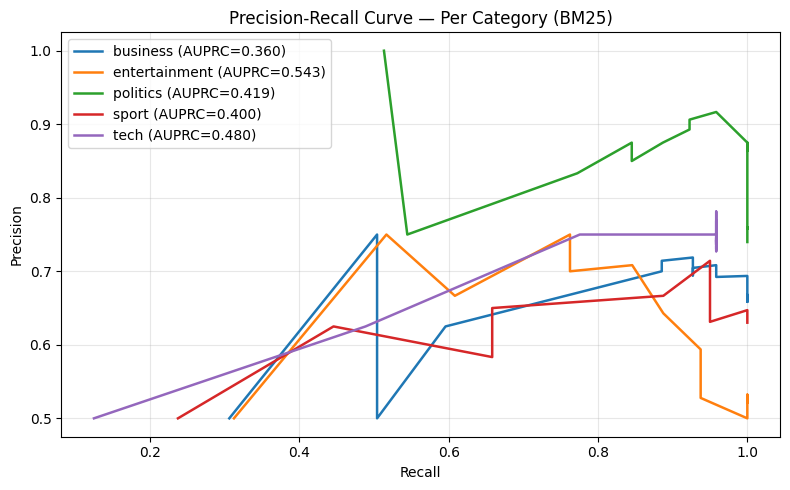

In [40]:
import matplotlib.pyplot as plt
from collections import Counter

Rset_all  = {d["doc_id"]: d["reference_summary"] for d in D}
eval_args = {"mode": "extractive", "p": 3, "beta": 1.0}

# ── Sample: 4 docs per category ───────────────────────────────────────────────
sample_docs = []
for cat in ["business", "entertainment", "politics", "sport", "tech"]:
    sample_docs.extend([d for d in D if d["category"] == cat][:4])

print(f"Sample: {len(sample_docs)} docs — {dict(Counter(d['category'] for d in sample_docs))}")

# ── Build full scored_pairs (all sentences, not just top-p) ───────────────────
all_summaries_full = {}
for doc in sample_docs:
    scores = get_sentence_scores(doc, D, I, method="bm25")
    all_summaries_full[doc["doc_id"]] = [(i, float(scores[i])) for i in range(len(scores))]

# ── Full collection ────────────────────────────────────────────────────────────
print("\n=== Full collection ===")
full_eval = evaluation(all_summaries_full, Rset_all, sample_docs, I, eval_args)
print(f"  Fβ (β=1, p=3) : {full_eval['f_beta_mean']:.4f} ± {full_eval['f_beta_std']:.4f}")
print(f"  AUPRC          : {full_eval['auprc_mean']:.4f} ± {full_eval['auprc_std']:.4f}")
print(f"  Documents      : {full_eval['n_docs']}")

# ── Per-category ──────────────────────────────────────────────────────────────
categories  = ["business", "entertainment", "politics", "sport", "tech"]
cat_results = {}

print("\n=== Per-category ===")
for cat in categories:
    cat_docs = [d for d in sample_docs if d["category"] == cat]
    cat_ids  = {d["doc_id"] for d in cat_docs}
    S_cat    = {k: v for k, v in all_summaries_full.items() if k in cat_ids}
    R_cat    = {k: v for k, v in Rset_all.items()           if k in cat_ids}
    if not S_cat:
        continue
    cat_eval         = evaluation(S_cat, R_cat, cat_docs, I, eval_args)
    cat_results[cat] = cat_eval
    print(f"  {cat:<15} Fβ={cat_eval['f_beta_mean']:.4f}±{cat_eval['f_beta_std']:.4f}  "
          f"AUPRC={cat_eval['auprc_mean']:.4f}±{cat_eval['auprc_std']:.4f}  (n={cat_eval['n_docs']})")

# ── Plot: PR curve per category ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
for cat in categories:
    if cat not in cat_results:
        continue
    ax.plot(cat_results[cat]["avg_recall_curve"],
            cat_results[cat]["avg_precision_curve"],
            lw=1.8, label=f"{cat} (AUPRC={cat_results[cat]['auprc_mean']:.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Per Category (BM25)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pr_curve_per_category.png", dpi=120)
plt.show()

### 4.2 IR Model Comparison — BM25 vs Embeddings vs RRF

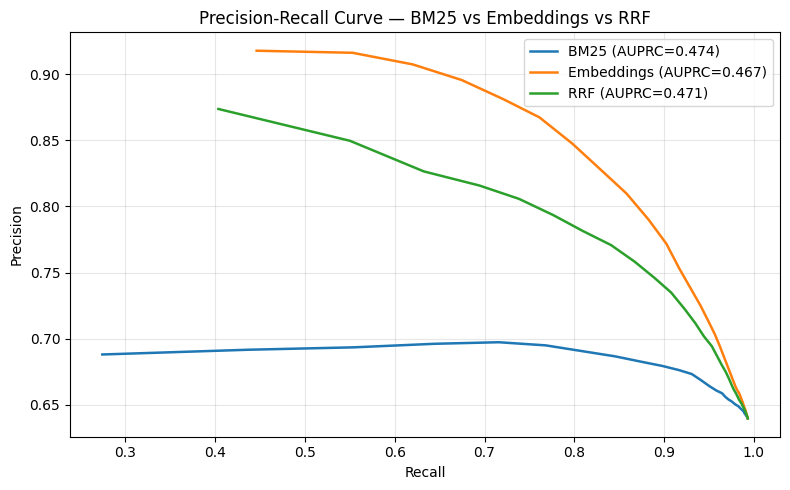

In [52]:
# Uses D[:100] for speed — replace with full D for final submission
categories = ["business", "entertainment", "politics", "sport", "tech"]

#for cat in categories:
    # 4 documentos da categoria
#    sample_docs_100 = [d for d in D if d["category"] == cat][:50]
sample_docs_100 = D

configs_pr = {
    "BM25":        {"method": "bm25",       "enc_key": "minilm_general"},
    "Embeddings":  {"method": "embeddings", "enc_key": "minilm_general"},
    "RRF":         {"method": "rrf",        "enc_key": "minilm_general"},
}

fig, ax = plt.subplots(figsize=(8, 5))
for label, cfg in configs_pr.items():
    S_full = {}
    for doc in sample_docs_100:
        if cfg["method"] == "rrf":
            s_bm25 = get_sentence_scores(doc, D, I, method="bm25",       enc_key=cfg["enc_key"])
            s_emb  = get_sentence_scores(doc, D, I, method="embeddings",  enc_key=cfg["enc_key"])
            scores = rrf_fusion([s_bm25, s_emb])
        else:
            scores = get_sentence_scores(doc, D, I, method=cfg["method"], enc_key=cfg["enc_key"])
        S_full[doc["doc_id"]] = [(i, float(scores[i])) for i in range(len(scores))]

    res = evaluation(S_full, Rset_all, sample_docs_100, I, eval_args)
    ax.plot(res["avg_recall_curve"], res["avg_precision_curve"],
            lw=1.8, label=f"{label} (AUPRC={res['auprc_mean']:.3f})")

ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — BM25 vs Embeddings vs RRF")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pr_curve_comparison.png", dpi=120)
plt.show()

### 4.3 MMR — Impact of λ

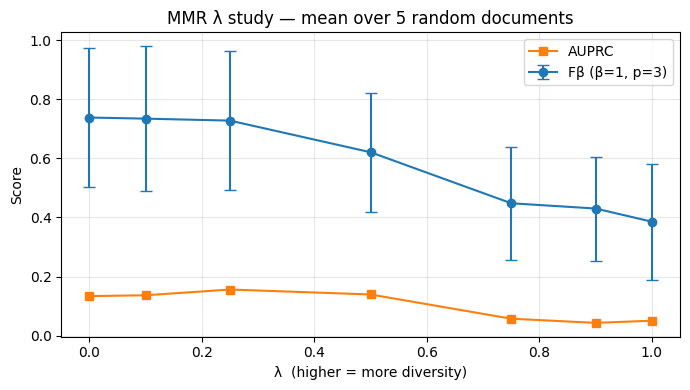


λ    | Fβ (mean) | Fβ (std) | AUPRC
---------------------------------------------
0.00 | 0.7388    | 0.2357   | 0.1335
0.10 | 0.7350    | 0.2456   | 0.1365
0.25 | 0.7283    | 0.2343   | 0.1559
0.50 | 0.6211    | 0.2008   | 0.1391
0.75 | 0.4482    | 0.1919   | 0.0570
0.90 | 0.4304    | 0.1763   | 0.0428
1.00 | 0.3858    | 0.1966   | 0.0502


In [48]:
import random
random.seed(42)
random_docs = random.sample(D, 50)

lambdas            = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
lambda_results_avg = {lam: {"f_beta": [], "auprc": []} for lam in lambdas}

for doc in random_docs:
    for lam in lambdas:
        scored = summarization(doc, 3, I, D, {"method": "bm25", "lambda": lam, "enc_key": "minilm_general"})
        res    = evaluation({doc["doc_id"]: scored}, {doc["doc_id"]: doc["reference_summary"]},
                            [doc], I, {"mode": "extractive", "p": 3, "beta": 1.0})
        lambda_results_avg[lam]["f_beta"].append(res["f_beta_mean"])
        lambda_results_avg[lam]["auprc"].append(res["auprc_mean"])

fb_means    = [np.mean(lambda_results_avg[lam]["f_beta"]) for lam in lambdas]
fb_stds     = [np.std(lambda_results_avg[lam]["f_beta"])  for lam in lambdas]
auprc_means = [np.mean(lambda_results_avg[lam]["auprc"])  for lam in lambdas]

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(lambdas, fb_means, yerr=fb_stds, marker="o", label="Fβ (β=1, p=3)", capsize=4)
ax.plot(lambdas, auprc_means, marker="s", label="AUPRC")
ax.set_xlabel("λ  (higher = more diversity)"); ax.set_ylabel("Score")
ax.set_title("MMR λ study — mean over 5 random documents")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("mmr_lambda_study_avg.png", dpi=120)
plt.show()

print("\nλ    | Fβ (mean) | Fβ (std) | AUPRC")
print("-" * 45)
for lam in lambdas:
    fb_m = np.mean(lambda_results_avg[lam]["f_beta"])
    fb_s = np.std(lambda_results_avg[lam]["f_beta"])
    au_m = np.mean(lambda_results_avg[lam]["auprc"])
    print(f"{lam:.2f} | {fb_m:.4f}    | {fb_s:.4f}   | {au_m:.4f}")

### 4.4 RRF & Encoder Comparison (MMR vs no MMR, general vs QA encoder)

In [46]:
# 4 docs per category for balanced comparison
sample_docs_balanced = []
for cat in ["business", "entertainment", "politics", "sport", "tech"]:
    sample_docs_balanced.extend([d for d in D if d["category"] == cat][:4])

Rset_sample = {d["doc_id"]: d["reference_summary"] for d in sample_docs_balanced}

configs = {
    "BM25 (no MMR)":    {"method": "bm25",       "lambda": 0.0, "enc_key": "minilm_general"},
    "BM25 + MMR":       {"method": "bm25",       "lambda": 0.5, "enc_key": "minilm_general"},
    "Embeddings":       {"method": "embeddings", "lambda": 0.5, "enc_key": "minilm_general"},
    "RRF":              {"method": "rrf",        "lambda": 0.5, "enc_key": "minilm_general"},
    "Embeddings (QA)":  {"method": "embeddings", "lambda": 0.5, "enc_key": "minilm_qa"},
    "RRF (QA)":         {"method": "rrf",        "lambda": 0.5, "enc_key": "minilm_qa"},
}

print("=== IR Model & RRF Comparison ===")
print(f"  {'Configuration':<22} {'Fβ':>8}  {'AUPRC':>8}")
print("  " + "-" * 42)
for label, cfg in configs.items():
    S_cfg = {doc["doc_id"]: summarization(doc, 3, I, D, cfg) for doc in sample_docs_balanced}
    res   = evaluation(S_cfg, Rset_sample, sample_docs_balanced, I,
                       {"mode": "extractive", "p": 3, "beta": 1.0})
    print(f"  {label:<22} {res['f_beta_mean']:>8.4f}  {res['auprc_mean']:>8.4f}")

=== IR Model & RRF Comparison ===
  Configuration                Fβ     AUPRC
  ------------------------------------------
  BM25 (no MMR)            0.7911    0.2158
  BM25 + MMR               0.6158    0.1780
  Embeddings               0.6158    0.1559
  RRF                      0.6158    0.1679
  Embeddings (QA)          0.5947    0.1431
  RRF (QA)                 0.5947    0.1483


### 4.5 Generative Evaluation — Cosine Similarity with Reference

In [47]:
# Load generative summaries
all_gen_summaries = joblib.load("summaries_generative_results.joblib")
all_summaries     = joblib.load("summaries_results.joblib")
Rset_all          = {d["doc_id"]: d["reference_summary"] for d in D}

print("=== Generative evaluation (cosine similarity with reference) ===")

# Auto-detect model keys from the file
first_id   = list(all_gen_summaries.keys())[0]
model_keys = list(all_gen_summaries[first_id].keys())

for model_key in model_keys:
    # Flatten nested dict if needed (model -> prompt -> summary)
    S_gen = {}
    for doc_id, sums in all_gen_summaries.items():
        if model_key not in sums:
            continue
        val = sums[model_key]
        # If nested by prompt key, take first prompt
        if isinstance(val, dict):
            val = list(val.values())[0]
        S_gen[doc_id] = val if isinstance(val, list) else [val]

    gen_eval = evaluation(S_gen, Rset_all, D, I, {"mode": "generative"})
    print(f"  {model_key:<35} cos_sim={gen_eval['cosine_sim_mean']:.4f} "
          f"± {gen_eval['cosine_sim_std']:.4f}  (n={gen_eval['n_docs']})")

# ── Extractive baseline (same metric for Q5 comparison) ──────────────────────
sample_ids = {d["doc_id"] for d in D[:20]}
S_ext_text = {}
for doc_id, scored_pairs in all_summaries.items():
    if doc_id not in sample_ids:
        continue
    doc = next((d for d in D if d["doc_id"] == doc_id), None)
    if doc:
        S_ext_text[doc_id] = [" ".join(doc["sentences"][pos] for pos, _ in scored_pairs)]

ext_eval = evaluation(S_ext_text, Rset_all, D[:20], I, {"mode": "generative"})
print(f"\n  {'Extractive (BM25+MMR)':<35} cos_sim={ext_eval['cosine_sim_mean']:.4f} "
      f"± {ext_eval['cosine_sim_std']:.4f}  (n={ext_eval['n_docs']})")

=== Generative evaluation (cosine similarity with reference) ===
  google/flan-t5-base                 cos_sim=0.7597 ± 0.0992  (n=20)
  facebook/bart-large-cnn             cos_sim=0.7253 ± 0.1042  (n=20)

  Extractive (BM25+MMR)               cos_sim=0.7807 ± 0.1056  (n=20)
